<a href="https://colab.research.google.com/github/JorgeBravo-CO/DB_2026-1_ANALITICA-DE-DATOS_G01/blob/main/Analitica_de_datos_Actividad_7_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Regresion para datos de energia de una planta de produccion

# 1. Librerias


In [198]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from pandas.core.frame import DataFrame
import plotly.express as px

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D

# 2. Datos


In [199]:
#forma 1:
Datos_Originales = pd.read_csv("https://raw.githubusercontent.com/JorgeBravo-CO/DB_2026-1_ANALITICA-DE-DATOS_G01/refs/heads/main/CONSUMO%20DE%20ENERGIA%20-%20Act%207-8.csv", sep=';', encoding='latin1')
Datos_Originales

,FECHA,ENERGIA-CONSUMIDA.FEM+ALCO-EXP,LINEAS DE PRODUCCION.LINEA 2.kWh dia,LINEAS DE PRODUCCION.SOLISTICA 3.kWh dia,LINEAS DE PRODUCCION.LINEA 2 - SOL 3.kWh dia,LINEAS DE PRODUCCION.LINEA 3.kWh dia,LINEAS DE PRODUCCION.LINEA 4.kWh dia,LINEAS DE PRODUCCION.LINEA 5.kWh dia,LINEAS DE PRODUCCION.LINEA 6.kWh dia,LINEAS DE PRODUCCION.LINEA 7 B&B AUX FABRICACION.kWh dia,...,AIRE COMPRIMIDO.ENERGIAA ELECTRICA AIRE FEMSA.kWh/dia,MEDIDORES DE GAS.LINEA MEDIA m3/dia.,LITROS DE BEBIDA.LITROS DE BEBIDA LB.,LITROS DE BEBIDA.LITROS DE BEBIDA LB-ACUMULADO-.,DETALLADO PRODUCCION.LITROS DE BEBIDA LB LINEA 2.,DETALLADO PRODUCCION.LITROS DE BEBIDA LB LINEA 3.,DETALLADO PRODUCCION.LITROS DE BEBIDA LB LINEA 4.,DETALLADO PRODUCCION.LITROS DE BEBIDA LB LINEA 5.,DETALLADO PRODUCCION.LITROS DE BEBIDA LB LINEA 6.,DETALLADO PRODUCCION.LITROS DE BEBIDA LB LINEA 7 BIB.
0,1/11/2025,"140.503,45","4.423,00",405,"4.018,00","4.108,00","2.865,00","3.331,00","2.102,00",881,...,"4.177,27","39.215,00","1.886.187,86","1.886.187,86","814.749,74","304.431,00","152.018,52","562.119,00",NaN,0
1,2/11/2025,"144.678,09","3.674,00",2,"3.672,00","4.750,00","2.912,00","3.683,00",262,890,...,"3.863,15","39.221,00","2.098.494,51","3.984.682,37","684.969,51","502.758,00","180.576,00","730.191,00","52.869,60",0
2,3/11/2025,"103.081,24",467,2,465,623,"2.844,00","3.693,00",140,867,...,"2.157,81","31.622,00","898.954,80","4.883.637,17",0,0,"81.826,80","377.064,00",0,0
3,4/11/2025,"136.786,13","4.556,00",397,"4.159,00","4.463,00","3.003,00","3.510,00","1.344,00","1.031,00",...,"3.696,62","40.791,00","2.144.793,91","7.028.431,08","863.453,63","405.336,00","203.821,44","608.526,00",0,"20.360,00"
4,5/11/2025,"152.059,90","4.835,00",413,"4.422,00","4.373,00","3.062,00","2.957,00","3.791,00","1.062,00",...,"3.605,01","40.751,00","2.281.743,72","9.310.174,80","1.016.722,52","372.096,00","247.435,20","489.040,00","28.188,00",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,27/12/2025,"147.509,55","4.861,00",401,"4.460,00","3.950,00","2.848,00","3.356,00","2.376,00",906,...,"2.776,16","33.982,00","2.159.823,58","57.695.753,47","1.140.471,58","267.264,00","174.576,00","577.512,00","118.965,60","53.498,50"
57,28/12/2025,"160.526,27","4.559,00",204,"4.355,00","4.132,00","2.885,00","3.334,00","3.984,00",789,...,"3.899,17","34.160,00","2.238.815,45","59.934.568,92","1.086.548,81","337.478,40","165.056,64","467.076,00","95.550,00",0
58,29/12/2025,"181.304,13","4.852,00",534,"4.318,00","3.736,00","3.234,00","3.588,00","3.463,00",893,...,"4.806,98","34.416,00","2.430.874,97","62.365.443,89","989.597,06","334.563,51","281.088,00","693.108,00","182.655,60","8.700,00"
59,30/12/2025,"186.085,53","5.019,00",245,"4.774,00","3.994,00","3.201,00","3.969,00",143,"1.055,00",...,"2.847,52","33.984,00","2.484.089,31","64.849.533,20","1.173.501,36","232.019,99","267.624,00","733.500,00","132.518,00","76.431,00"


In [200]:
datos = Datos_Originales.copy()

In [201]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 42 columns):
 #   Column                                                                                                  Non-Null Count  Dtype 
---  ------                                                                                                  --------------  ----- 
 0   FECHA                                                                                                   61 non-null     object
 1   ENERGIA-CONSUMIDA.FEM+ALCO-EXP                                                                          61 non-null     object
 2   LINEAS DE PRODUCCION.LINEA 2.kWh dia                                                                   61 non-null     object
 3   LINEAS DE PRODUCCION.SOLISTICA 3.kWh dia                                                                61 non-null     int64 
 4   LINEAS DE PRODUCCION.LINEA 2 - SOL 3.kWh dia                                                       

In [202]:
# Convertir la columna 'FECHA' a formato datetime
datos['FECHA'] = pd.to_datetime(datos['FECHA'], format='%d/%m/%Y')

# Identificar columnas que deberían ser numéricas pero son de tipo 'object'
# Excluyendo 'FECHA' que ya hemos manejado
numeric_cols_to_clean = datos.select_dtypes(include='object').columns.tolist()

# Limpiar y convertir columnas numéricas
for col in numeric_cols_to_clean:
    if col != 'FECHA': # 'FECHA' is already handled
        # Replace dots (thousands separator) and commas (decimal separator)
        datos[col] = datos[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
        # Convert to numeric, coercing errors to NaN
        datos[col] = pd.to_numeric(datos[col], errors='coerce')

# Llenar valores NaN con 0 después de la conversión para las columnas numéricas que se limpiaron
# Esto es una suposición; se podría considerar la media, mediana o imputación más sofisticada
for col in numeric_cols_to_clean:
    if col != 'FECHA': # 'FECHA' does not need NaN fill for numeric data
        datos[col] = datos[col].fillna(0)

# Mostrar la información del DataFrame después de la limpieza para verificar tipos de datos
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 42 columns):
 #   Column                                                                                                  Non-Null Count  Dtype         
---  ------                                                                                                  --------------  -----         
 0   FECHA                                                                                                   61 non-null     datetime64[ns]
 1   ENERGIA-CONSUMIDA.FEM+ALCO-EXP                                                                          61 non-null     float64       
 2   LINEAS DE PRODUCCION.LINEA 2.kWh dia                                                                   61 non-null     float64       
 3   LINEAS DE PRODUCCION.SOLISTICA 3.kWh dia                                                                61 non-null     int64         
 4   LINEAS DE PRODUCCION.LINEA 2 - SOL 3.kWh dia       

#4. Conversión de Columnas a `float64`

Procederemos a convertir las columnas especificadas por el usuario a tipo `float64` para asegurar la uniformidad en los tipos de datos numéricos. Esto incluye las columnas en las posiciones 3, 11, 15, 16 y 17.

In [203]:
# Columnas a convertir a float64 (usando el índice basado en 0)
columns_to_convert_to_float = [3, 11, 15, 16, 17]

# Obtener los nombres de las columnas usando los índices
column_names = datos.columns[columns_to_convert_to_float]

# Convertir las columnas a float64
for col_name in column_names:
    datos[col_name] = datos[col_name].astype('float64')

# Mostrar la información del DataFrame después de la conversión para verificar tipos de datos
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 42 columns):
 #   Column                                                                                                  Non-Null Count  Dtype         
---  ------                                                                                                  --------------  -----         
 0   FECHA                                                                                                   61 non-null     datetime64[ns]
 1   ENERGIA-CONSUMIDA.FEM+ALCO-EXP                                                                          61 non-null     float64       
 2   LINEAS DE PRODUCCION.LINEA 2.kWh dia                                                                   61 non-null     float64       
 3   LINEAS DE PRODUCCION.SOLISTICA 3.kWh dia                                                                61 non-null     float64       
 4   LINEAS DE PRODUCCION.LINEA 2 - SOL 3.kWh dia       

#5. Creación de Nueva Columna:
#División entre Litros de bebida y consumo electrico

Crearemos una nueva columna que representará la división entre los valores de la columna en la posición 19 y la columna en la posición 34. Es crucial manejar los casos de división por cero para evitar errores en el cálculo. Para ello, añadiremos una pequeña constante al denominador.

In [204]:
indicadores = DataFrame()

# Nombres de las columnas basadas en sus índices (0-based)
dummy_b = datos.columns[19] # Columna en la posición 19 - CONSUMO ENERGIAA ELECTRICA POR USUARIOS PIF.CONSUMO TOTAL ENERGIAA ELECTRICA FEMSA.INDICADOR.kWh dia
dummy_a = datos.columns[34] # Columna en la posición 34 - LITROS DE BEBIDA.LITROS DE BEBIDA LB.

# Crear la nueva columna con la división, manejando la división por cero
# Se añade un pequeño valor (epsilon) al denominador para evitar errores de división por cero
epsilon = 1e-6 # Una pequeña constante para evitar división por cero
indicadores['indicador_energia_planta.lb/kw'] = datos[dummy_a] / (datos[dummy_b] + epsilon)
datos['indicador_energia_planta.lb/kw'] = datos[dummy_a] / (datos[dummy_b] + epsilon)

# Mostrar las columnas relevantes y la nueva columna para verificar el resultado
# display(datos[[column_19_energia_indicador, column_34_litros_bebida, 'indicador_energia_planta.lb/kw']].head())

dummy_a = datos.columns[36] # Columna en la posición 36 - DETALLADO PRODUCCION.LITROS DE BEBIDA LB LINEA 2.
dummy_b = datos.columns[2] # Columna en la posición 2 - LINEAS DE PRODUCCION.LINEA 2.kWh dia
indicadores['indicador_energia_L2.lb/kw'] = datos[dummy_a] / (datos[dummy_b] + epsilon)

dummy_a = datos.columns[37] # Columna en la posición 37 - DETALLADO PRODUCCION.LITROS DE BEBIDA LB LINEA 3.
dummy_b = datos.columns[5] # Columna en la posición 5 - LINEAS DE PRODUCCION.LINEA 3.kWh dia
indicadores['indicador_energia_L3.lb/kw'] = datos[dummy_a] / (datos[dummy_b] + epsilon)

dummy_a = datos.columns[38] # Columna en la posición 38 - DETALLADO PRODUCCION.LITROS DE BEBIDA LB LINEA 4.
dummy_b = datos.columns[6] # Columna en la posición 6 - LINEAS DE PRODUCCION.LINEA 4.kWh dia
indicadores['indicador_energia_L4.lb/kw'] = datos[dummy_a] / (datos[dummy_b] + epsilon)

dummy_a = datos.columns[39] # Columna en la posición 39 - DETALLADO PRODUCCION.LITROS DE BEBIDA LB LINEA 5.
dummy_b = datos.columns[7] # Columna en la posición 7 - LINEAS DE PRODUCCION.LINEA 5.kWh dia
indicadores['indicador_energia_L5.lb/kw'] = datos[dummy_a] / (datos[dummy_b] + epsilon)

dummy_a = datos.columns[40] # Columna en la posición 40 - DETALLADO PRODUCCION.LITROS DE BEBIDA LB LINEA 6.
dummy_b = datos.columns[8] # Columna en la posición 8 - LINEAS DE PRODUCCION.LINEA 6.kWh dia
indicadores['indicador_energia_L6.lb/kw'] = datos[dummy_a] / (datos[dummy_b] + epsilon)

dummy_a = datos.columns[41] # Columna en la posición 41 - DETALLADO PRODUCCION.LITROS DE BEBIDA LB LINEA 7.
dummy_b = datos.columns[9] # Columna en la posición 9 - LINEAS DE PRODUCCION.LINEA 7.kWh dia
indicadores['indicador_energia_L7.lb/kw'] = datos[dummy_a] / (datos[dummy_b] + epsilon)

dummy_a = datos.columns[34] # Columna en la posición 34 - LITROS DE BEBIDA.LITROS DE BEBIDA LB
dummy_b = datos.columns[20] # Columna en la posición 20 - REFRIGERACION.GLICOL AGUA HELADA.Kwh/dia
indicadores['indicador_refrigeracion.lb/kw'] = datos[dummy_a] / (datos[dummy_b] + epsilon)

dummy_a = datos.columns[34] # Columna en la posición 34 - LITROS DE BEBIDA.LITROS DE BEBIDA LB
dummy_b = datos.columns[32] # Columna en la posición 32 - AIRE COMPRIMIDO.ENERGIAA ELECTRICA AIRE FEMSA.kWh/dia
indicadores['indicador_aire_comprimido.lb/kw'] = datos[dummy_a] / (datos[dummy_b] + epsilon)

In [205]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 43 columns):
 #   Column                                                                                                  Non-Null Count  Dtype         
---  ------                                                                                                  --------------  -----         
 0   FECHA                                                                                                   61 non-null     datetime64[ns]
 1   ENERGIA-CONSUMIDA.FEM+ALCO-EXP                                                                          61 non-null     float64       
 2   LINEAS DE PRODUCCION.LINEA 2.kWh dia                                                                   61 non-null     float64       
 3   LINEAS DE PRODUCCION.SOLISTICA 3.kWh dia                                                                61 non-null     float64       
 4   LINEAS DE PRODUCCION.LINEA 2 - SOL 3.kWh dia       

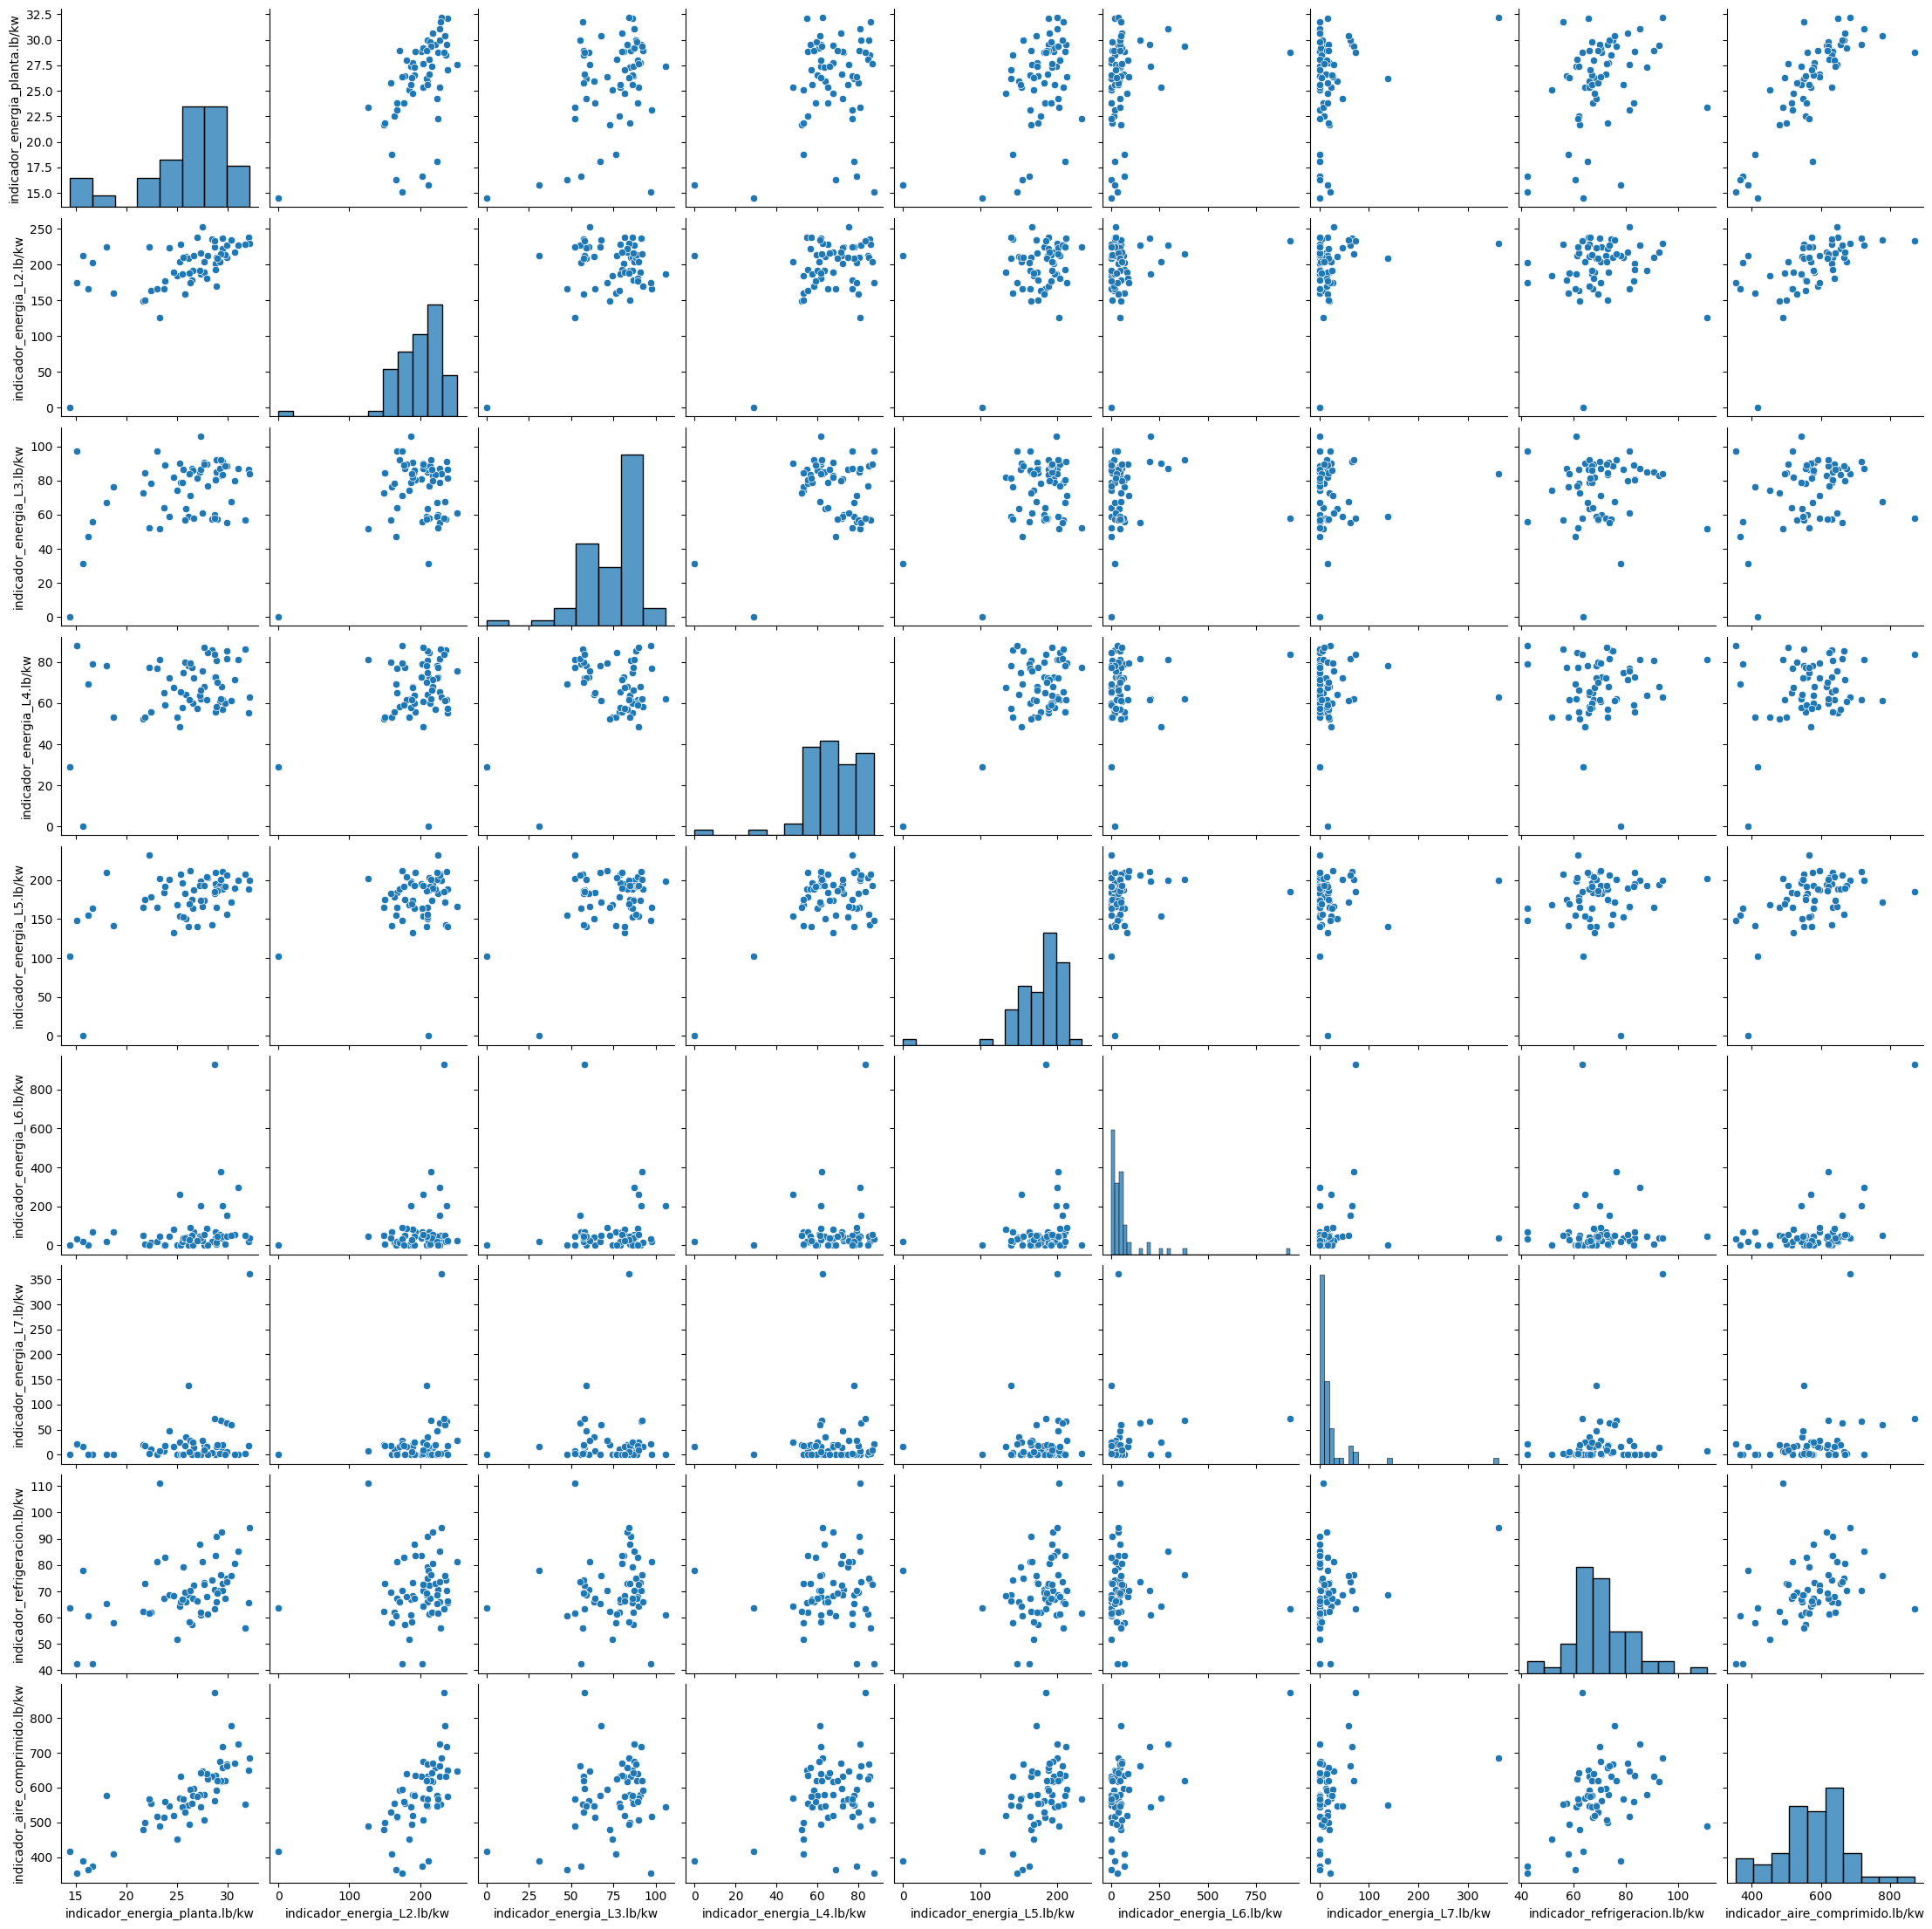

In [206]:
sns.pairplot(indicadores)

In [207]:
indicadores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   indicador_energia_planta.lb/kw   61 non-null     float64
 1   indicador_energia_L2.lb/kw       61 non-null     float64
 2   indicador_energia_L3.lb/kw       61 non-null     float64
 3   indicador_energia_L4.lb/kw       61 non-null     float64
 4   indicador_energia_L5.lb/kw       61 non-null     float64
 5   indicador_energia_L6.lb/kw       61 non-null     float64
 6   indicador_energia_L7.lb/kw       61 non-null     float64
 7   indicador_refrigeracion.lb/kw    61 non-null     float64
 8   indicador_aire_comprimido.lb/kw  61 non-null     float64
dtypes: float64(9)
memory usage: 4.4 KB


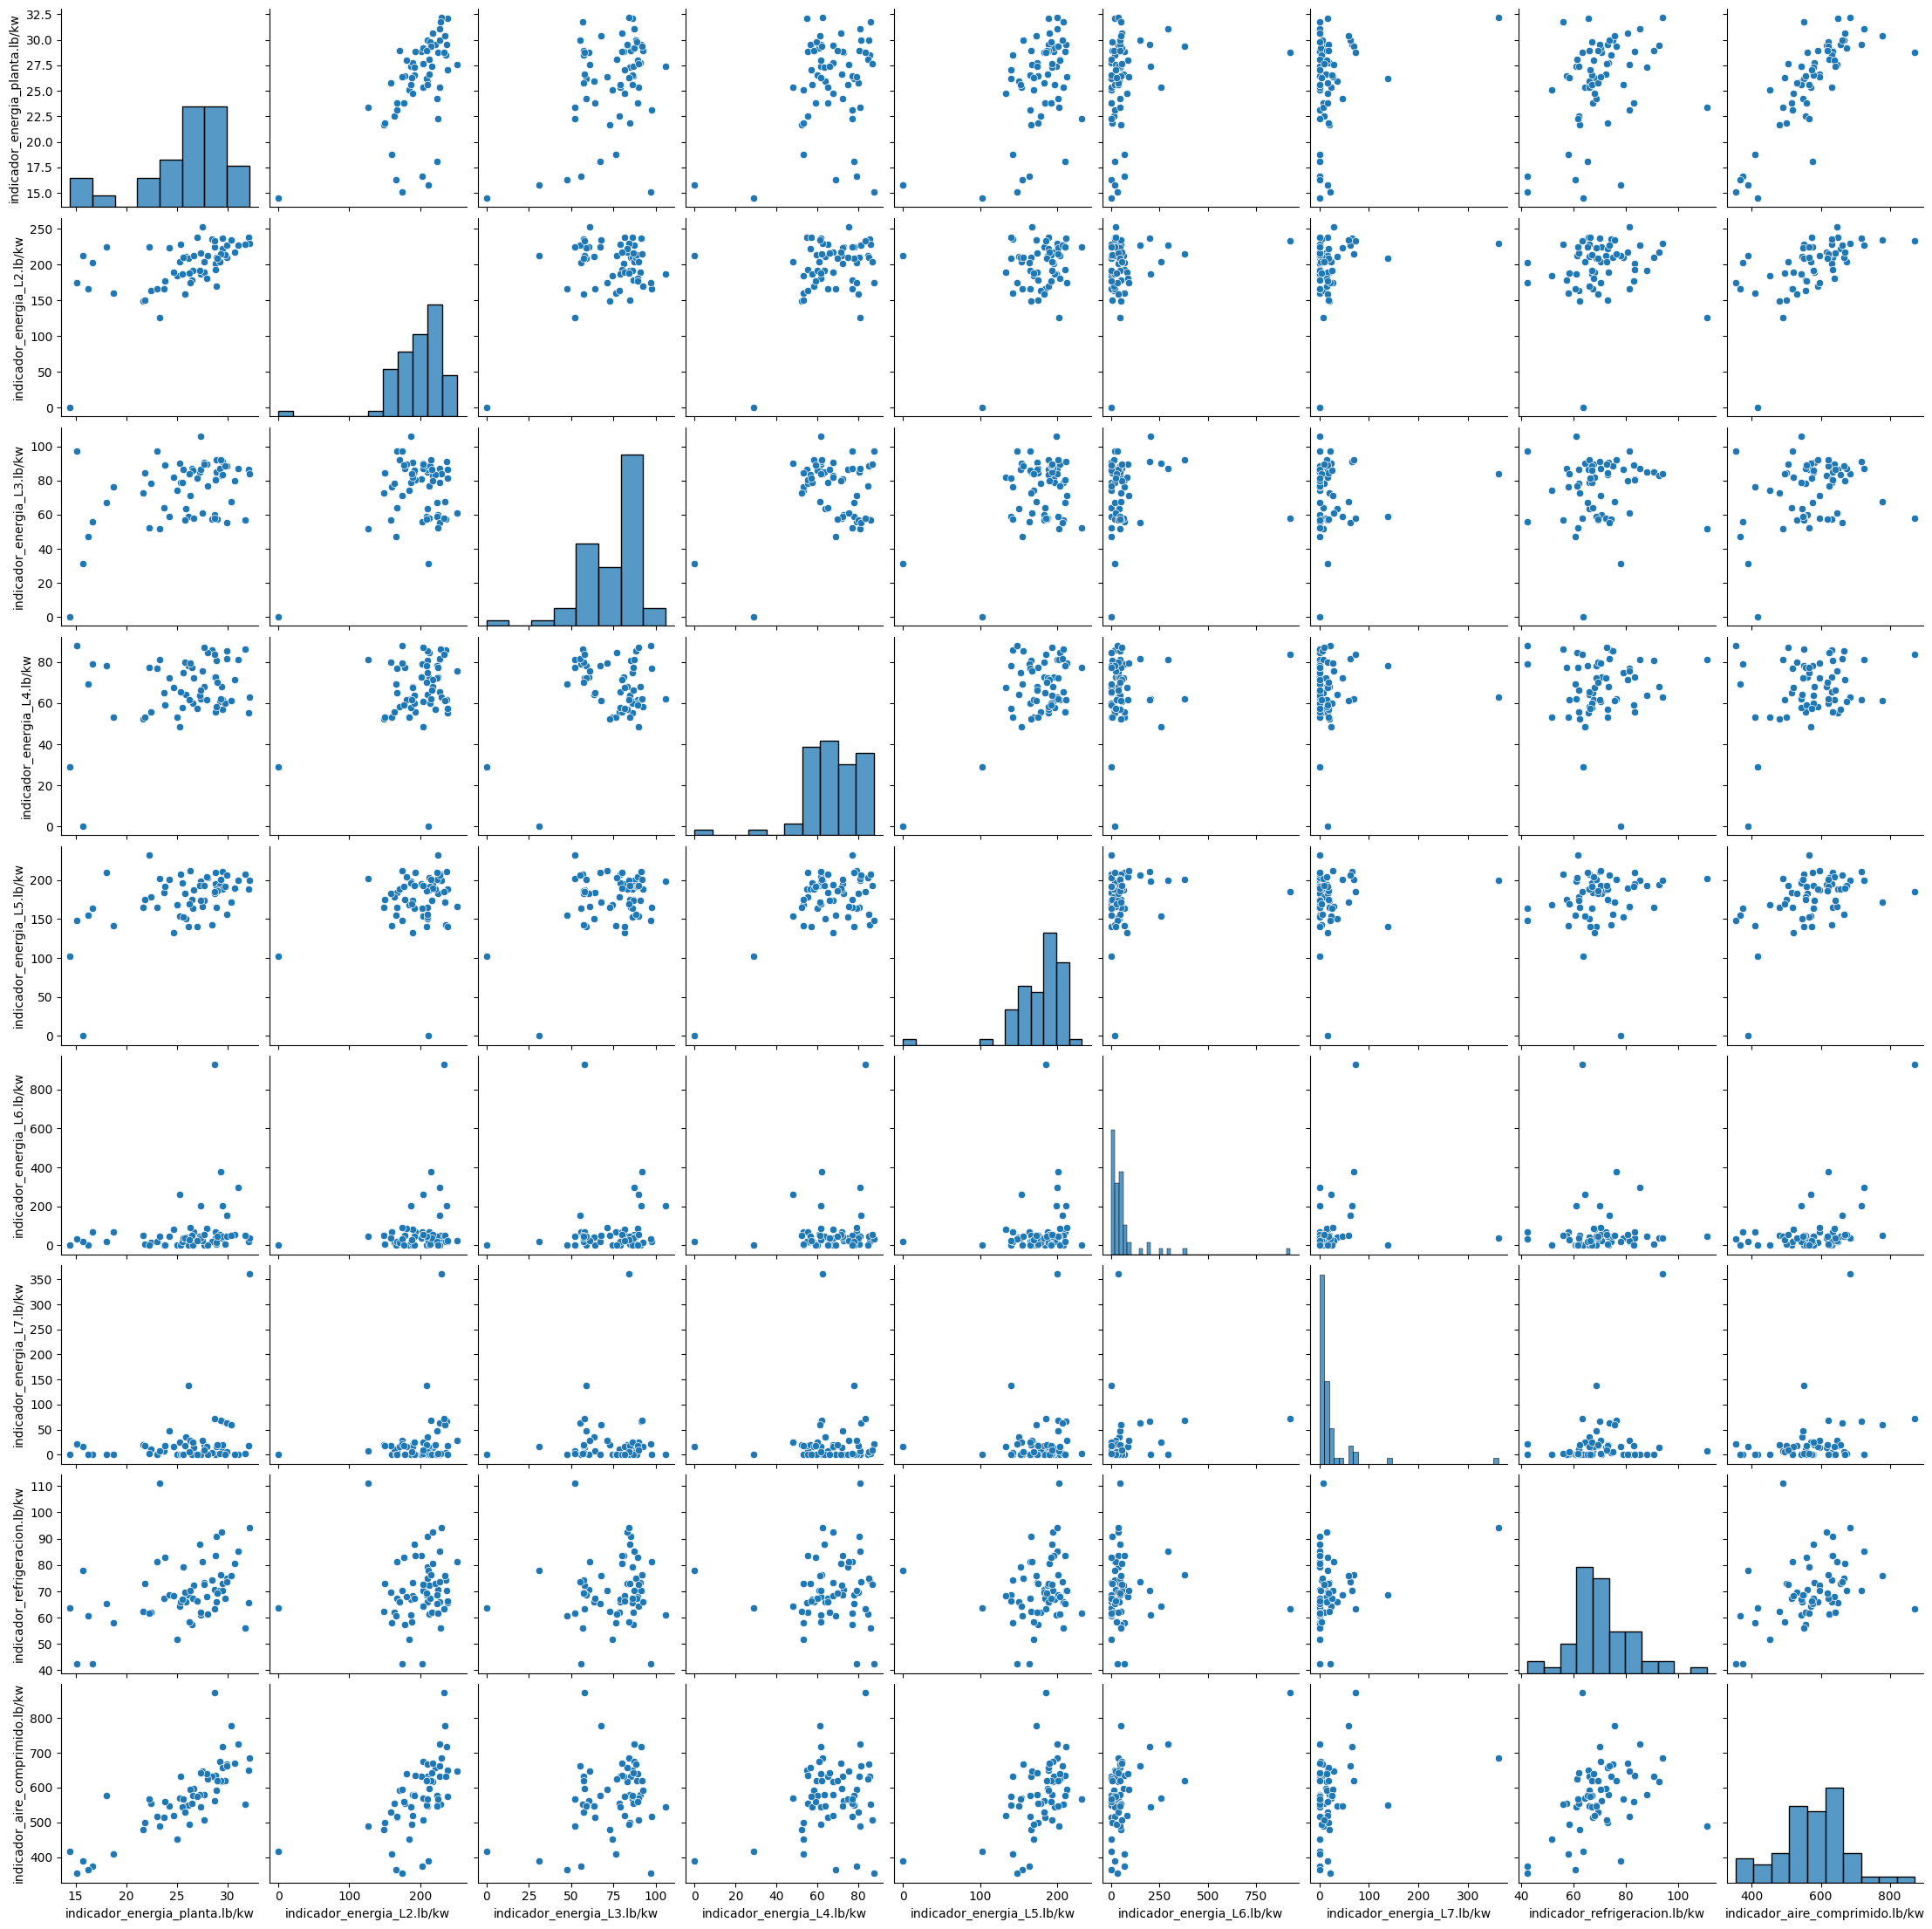

In [208]:
sns.pairplot(indicadores)

<Axes: >

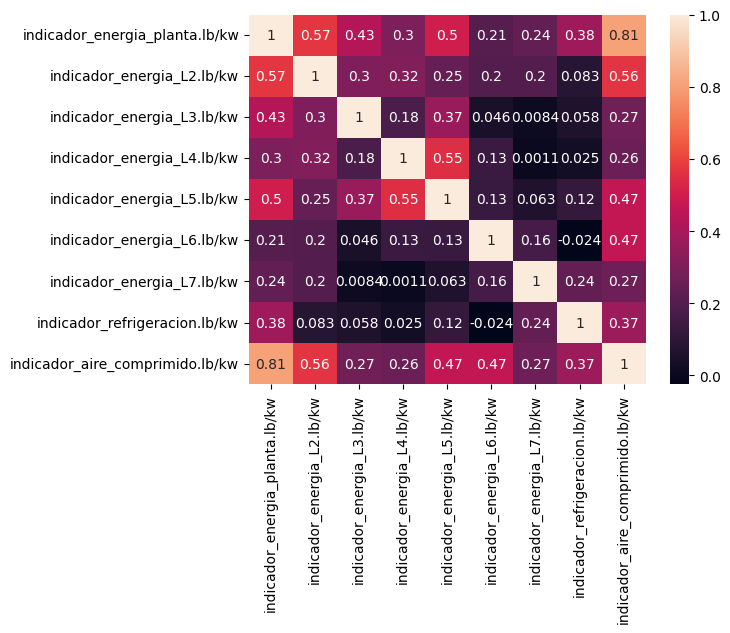

In [209]:
matriz_corr = indicadores.corr()
sns.heatmap(matriz_corr, annot=True)

# Determinacion de la variable a deducir

In [210]:
x = datos.drop(["indicador_energia_planta.lb/kw", "FECHA"], axis = 1)
y = datos["indicador_energia_planta.lb/kw"]

## 7. Regresión Lineal

Procederemos a evaluar el rendimiento del modelo de regresión lineal utilizando métricas clave como el Error Cuadrático Medio (MSE), el Error Absoluto Medio (MAE) y el coeficiente de determinación R-cuadrado. Estas métricas nos permitirán entender la precisión y la capacidad predictiva del modelo en el conjunto de prueba.

In [211]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [212]:
modelo_lineal = LinearRegression()
modelo_lineal.fit(x_train, y_train)

LinearRegression()

In [213]:
# Realizar predicciones en el conjunto de prueba
y_pred_lineal = modelo_lineal.predict(x_test)

# Calcular métricas de evaluación
mse_lineal = mean_squared_error(y_test, y_pred_lineal)
mae_lineal = mean_absolute_error(y_test, y_pred_lineal)
r2_lineal = r2_score(y_test, y_pred_lineal)

print(f'Métricas del Modelo de Regresión Lineal:')
print(f'Mean Squared Error (MSE): {mse_lineal:.4f}')
print(f'Mean Absolute Error (MAE): {mae_lineal:.4f}')
print(f'R-squared (R2): {r2_lineal:.4f}')


Métricas del Modelo de Regresión Lineal:
Mean Squared Error (MSE): 0.3782
Mean Absolute Error (MAE): 0.4842
R-squared (R2): 0.9842


Text(0, 0.5, 'Valor')

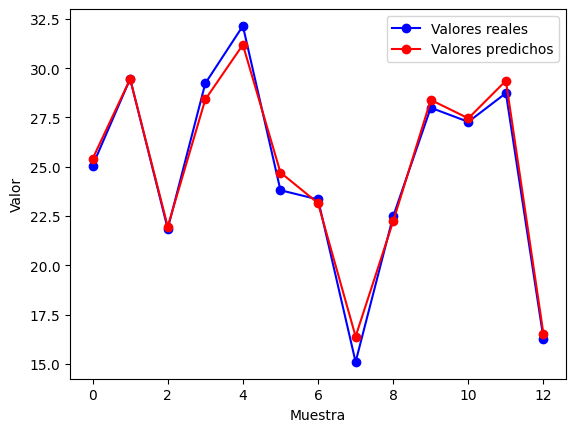

In [214]:
plt.plot(np.array(y_test),"bo-")
plt.plot(np.array(y_pred_lineal),"ro-")
plt.legend(["Valores reales","Valores predichos"])
plt.xlabel("Muestra")
plt.ylabel("Valor")

## 8. Regresión Polinomial

In [215]:
ModeloPol = PolynomialFeatures(degree=2)
x_pol = ModeloPol.fit_transform(x)
#print(x_pol)
#print(x)

In [216]:
x_train_pol, x_test_pol, y_train_pol, y_test_pol = train_test_split(x_pol, y, test_size=0.2, random_state=42)
#print(x_test_pol)
#print(y_test_pol)

In [217]:
#Regresión lineal transformada a grado 2
modelo_linealpol = LinearRegression()
# 2. Entrenamiento
modelo_linealpol.fit(x_train_pol, y_train_pol)
# 3. Predicción
y_pred_pol = modelo_linealpol.predict(x_test_pol)
#print(y_pred_pol)
# Calcular métricas de evaluación
mse_polinomial = mean_squared_error(y_test, y_pred_pol)
mae_polinomial = mean_absolute_error(y_test, y_pred_pol)
r2_polinomial = r2_score(y_test, y_pred_pol)

print(f'Métricas del Modelo de Regresión Lineal:')
print(f'Mean Squared Error (MSE): {mse_polinomial:.4f}')
print(f'Mean Absolute Error (MAE): {mae_polinomial:.4f}')
print(f'R-squared (R2): {r2_polinomial:.4f}')


Métricas del Modelo de Regresión Lineal:
Mean Squared Error (MSE): 5.8863
Mean Absolute Error (MAE): 1.9487
R-squared (R2): 0.7539


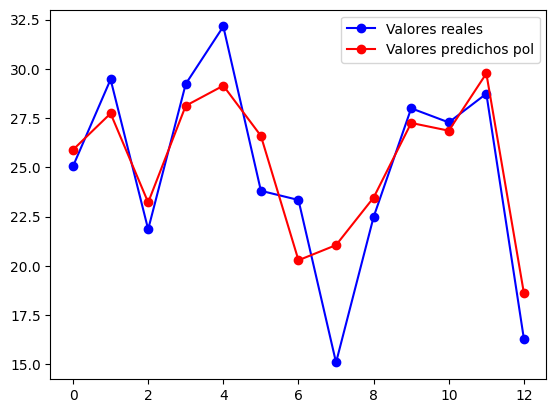

In [218]:
plt.plot(np.array(y_test_pol), "bo-")
plt.plot(np.array(y_pred_pol), "ro-")
plt.legend(["Valores reales", "Valores predichos pol"])
plt.show()

## Arbol de regresion

No aplica para estos datos de regresión

In [219]:
#from sklearn.tree import DecisionTreeRegressor
# 1. Crear modelo
modeloarbol = DecisionTreeRegressor(max_depth=6, criterion="squared_error", random_state=42)
# 2. Entrenar modelo
modeloarbol.fit(x_train, y_train)
# 3. Predicción
y_pred_arbol = modeloarbol.predict(x_test)
##print(y_pred_arbol)

In [220]:
# gráfica del árbol
##fig = plt.figure(figsize=(150, 100))
##tree.plot_tree(modeloarbol, filled=True, feature_names=x.columns, precision=2)

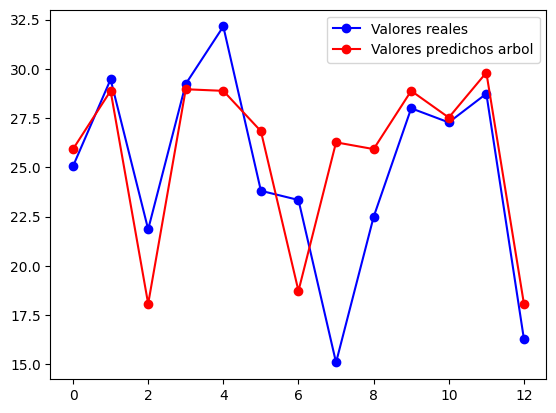

In [221]:
plt.plot(np.array(y_test), "bo-")
plt.plot(np.array(y_pred_arbol), "ro-")
plt.legend(["Valores reales", "Valores predichos arbol"])
plt.show()

In [222]:
# 4. Métricas de evaluación
arbol_mse = mean_squared_error(y_test, y_pred_arbol)
arbol_mae = mean_absolute_error(y_test, y_pred_arbol)
arbol_r2 = r2_score(y_test, y_pred_arbol)

print(f'Métricas del Modelo de Regresión Lineal:')
print(f'Mean Squared Error (MSE): {arbol_mse:.4f}')
print(f'Mean Absolute Error (MAE): {arbol_mae:.4f}')
print(f'R-squared (R2): {arbol_r2:.4f}')


Métricas del Modelo de Regresión Lineal:
Mean Squared Error (MSE): 15.2558
Mean Absolute Error (MAE): 2.6925
R-squared (R2): 0.3623


## Maquinas de soporte vectorial

In [223]:
# tomó mas de 20 min sin resultados

In [224]:
#1. Definir el modelo
##modeloMSV = SVR(kernel="linear", C=10, gamma="auto")
#2. Entrenar
##modeloMSV.fit(x_train, y_train)
#3. Predicción - testear
##y_pred_MSV = modeloMSV.predict(x_test)
##print(y_pred_MSV)

In [225]:
##plt.plot(np.array(y_test), "bo-")
##plt.plot(np.array(y_pred_MSV), "ro-")
##plt.legend(["Valores reales", "Valores predichos MSV"])
##plt.show()

In [226]:
# 4. Métricas de evaluación
##print(f"MSE: {mean_squared_error(y_test, y_pred_MSV):.4f}")
##print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_MSV)):.4f}")
##print(f"MAE: {mean_absolute_error(y_test, y_pred_MSV):.4f}")
##print(f"R2: {r2_score(y_test, y_pred_MSV):.4f}")

## Bosques aleatorios

In [227]:
# 1. Definir el modelo
modeloBR = RandomForestRegressor(n_estimators=300, max_depth=6, random_state=942)
# 2. Entrenar
modeloBR.fit(x_train, y_train)
# 3. Predicción
y_pred_BR = modeloBR.predict(x_test)
#print(y_pred_BR)

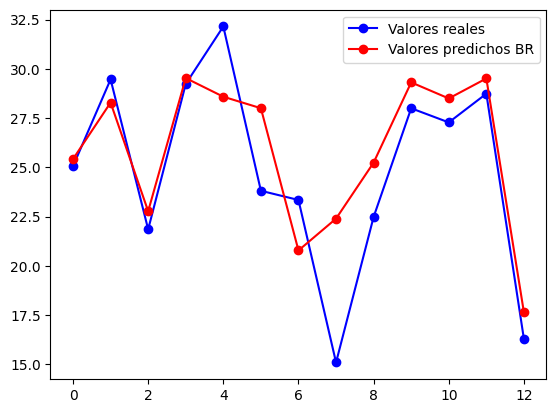

In [228]:
plt.plot(np.array(y_test), "bo-")
plt.plot(np.array(y_pred_BR), "ro-")
plt.legend(["Valores reales", "Valores predichos BR"])
plt.show()

In [229]:
BR_mse = mean_squared_error(y_test, y_pred_BR)
BR_mae = mean_absolute_error(y_test, y_pred_BR)
BR_r2 = r2_score(y_test, y_pred_arbol)

print(f'Métricas del Modelo de Regresión Lineal:')
print(f'Mean Squared Error (MSE):{BR_mse:.4f}')
print(f'Mean Absolute Error (MAE):{BR_mae:.4f}')
print(f'R-squared (R2):{BR_r2:.4f}')

Métricas del Modelo de Regresión Lineal:
Mean Squared Error (MSE):8.1348
Mean Absolute Error (MAE):2.1367
R-squared (R2):0.3623


## Gradiente

In [230]:
from sklearn.ensemble import GradientBoostingRegressor
# 1. Definir modelo
modeloG = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=234)
# 2. Entrenar
modeloG.fit(x_train, y_train)
# 3. Predecir
y_pred_G = modeloG.predict(x_test)
##print(y_pred_G)

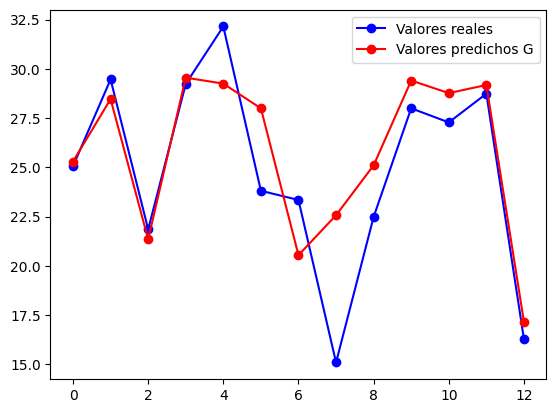

In [231]:
plt.plot(np.array(y_test), "bo-")
plt.plot(np.array(y_pred_G), "ro-")
plt.legend(["Valores reales", "Valores predichos G"])
plt.show()

In [232]:
G_MSE = mean_squared_error(y_test, y_pred_G)
G_MAE = mean_absolute_error(y_test, y_pred_G)
G_R2 = r2_score(y_test, y_pred_G)

print(f'Métricas del Modelo de Regresión Lineal:')
print(f'Mean Squared Error (MSE):{G_MSE:.4f}')
print(f'Mean Absolute Error (MAE):{G_MAE:.4f}')
print(f'R-squared (R2):{G_R2:.4f}')


Métricas del Modelo de Regresión Lineal:
Mean Squared Error (MSE):7.9226
Mean Absolute Error (MAE):2.0190
R-squared (R2):0.6688


# Graficas de comparación R2

In [233]:
#import plotly.express as px

fig = px.bar(x=model_names, y=r2_scores,
             labels={'x': 'Modelos de Regresión', 'y': 'R-squared (R2)'},
             title='Comparación de R-squared para diferentes Modelos (Plotly)',
             color=r2_scores, # Color bars based on R2 score
             color_continuous_scale=px.colors.sequential.Viridis)
fig.update_layout(yaxis_range=[0, 1]) # R2 score is between 0 and 1
fig.show()

# K-Means Clustering

In [247]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 43 columns):
 #   Column                                                                                                  Non-Null Count  Dtype         
---  ------                                                                                                  --------------  -----         
 0   FECHA                                                                                                   61 non-null     datetime64[ns]
 1   ENERGIA-CONSUMIDA.FEM+ALCO-EXP                                                                          61 non-null     float64       
 2   LINEAS DE PRODUCCION.LINEA 2.kWh dia                                                                   61 non-null     float64       
 3   LINEAS DE PRODUCCION.SOLISTICA 3.kWh dia                                                                61 non-null     float64       
 4   LINEAS DE PRODUCCION.LINEA 2 - SOL 3.kWh dia       

In [251]:
# To select columns by their integer positions, use .iloc
column_indices = [19, 2, 5, 6, 7, 8, 9, 36, 37, 38, 39, 40, 41]
X = datos.iloc[:, column_indices]
Y = datos["indicador_energia_planta.lb/kw"]
X.shape
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 13 columns):
 #   Column                                                                                                  Non-Null Count  Dtype  
---  ------                                                                                                  --------------  -----  
 0   CONSUMO ENERGIAA ELECTRICA POR USUARIOS PIF.CONSUMO TOTAL ENERGIAA ELECTRICA FEMSA.INDICADOR.kWh dia  61 non-null     float64
 1   LINEAS DE PRODUCCION.LINEA 2.kWh dia                                                                   61 non-null     float64
 2   LINEAS DE PRODUCCION.LINEA 3.kWh dia                                                                   61 non-null     float64
 3   LINEAS DE PRODUCCION.LINEA 4.kWh dia                                                                   61 non-null     float64
 4   LINEAS DE PRODUCCION.LINEA 5.kWh dia                                                         

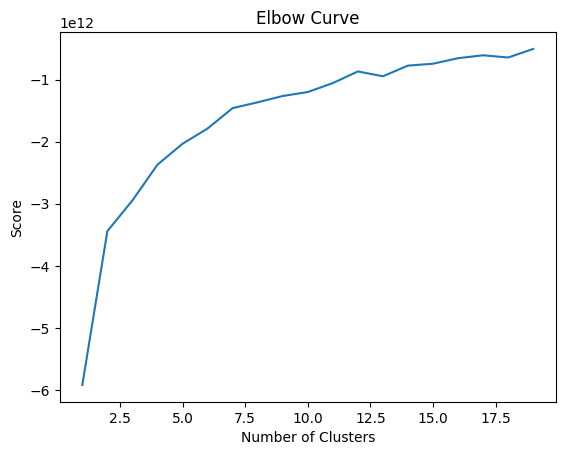

In [252]:
Nc = range(1,20)
kmeans = [KMeans(n_clusters=i) for i in Nc]
kmeans
score = [kmeans[i].fit(X).score(X) for i in range(len(kmeans))]
score
plt.plot(Nc,score)
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.title('Elbow Curve')
plt.show()

In [253]:
kmeans = KMeans(n_clusters=5).fit(X)
centroids = kmeans.cluster_centers_
print(centroids)

[[8.24634229e+04 5.01076471e+03 4.15370588e+03 3.05723529e+03
  3.54488235e+03 2.39382353e+03 1.01194118e+03 1.13731115e+06
  3.01247081e+05 2.17507082e+05 6.69152407e+05 1.16671494e+05
  5.23849059e+04]
 [7.54851507e+04 3.58733333e+03 3.30753333e+03 2.81166667e+03
  3.13853333e+03 2.13086667e+03 9.83133333e+02 6.23242671e+05
  2.50467659e+05 1.92793720e+05 5.66000667e+05 6.33402827e+04
  7.33681667e+03]
 [6.21055400e+04 4.67000000e+02 6.23000000e+02 2.84400000e+03
  3.69300000e+03 1.40000000e+02 8.67000000e+02 0.00000000e+00
  0.00000000e+00 8.18268000e+04 3.77064000e+05 0.00000000e+00
  0.00000000e+00]
 [8.05369948e+04 4.73322222e+03 4.16514815e+03 2.91266667e+03
  3.28970370e+03 2.78651852e+03 9.83074074e+02 9.43608623e+05
  3.37089434e+05 2.00352379e+05 5.85617741e+05 1.00741375e+05
  1.57912759e+04]
 [6.50681600e+04 3.70700000e+03 8.56000000e+02 1.38000000e+02
  1.62000000e+02 3.43700000e+03 1.04100000e+03 7.85928000e+05
  2.65920000e+04 0.00000000e+00 0.00000000e+00 7.14240000e+0

In [254]:
#from mpl_toolkits.mplot3d import Axes3D

# Predecir los clusters
labels = kmeans.predict(X)
print(labels)

#Obtener el centro de los clusters
C = kmeans.cluster_centers_
colores=['red','green','blue','cyan','yellow'] # Added 'purple' to match 5 clusters
asignar=[]
for row in labels:
    asignar.append(colores[row])

fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X.iloc[:,0], X.iloc[:,1], X.iloc[:,2], c=asignar, s=60)
ax.scatter(C[:,0], C[:,1], C[:,2], marker='*', c=colores, s=1000)

[3 1 2 3 3 3 1 3 0 1 0 3 1 0 3 1 1 3 1 3 0 3 0 0 1 3 3 3 3 0 0 3 0 3 1 1 3
 4 3 3 3 3 0 0 0 3 1 0 3 1 3 0 0 1 1 3 0 3 3 0 1]


<Figure size 640x480 with 0 Axes>

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 141 (\x8d) missing from font(s) DejaVu Sans.



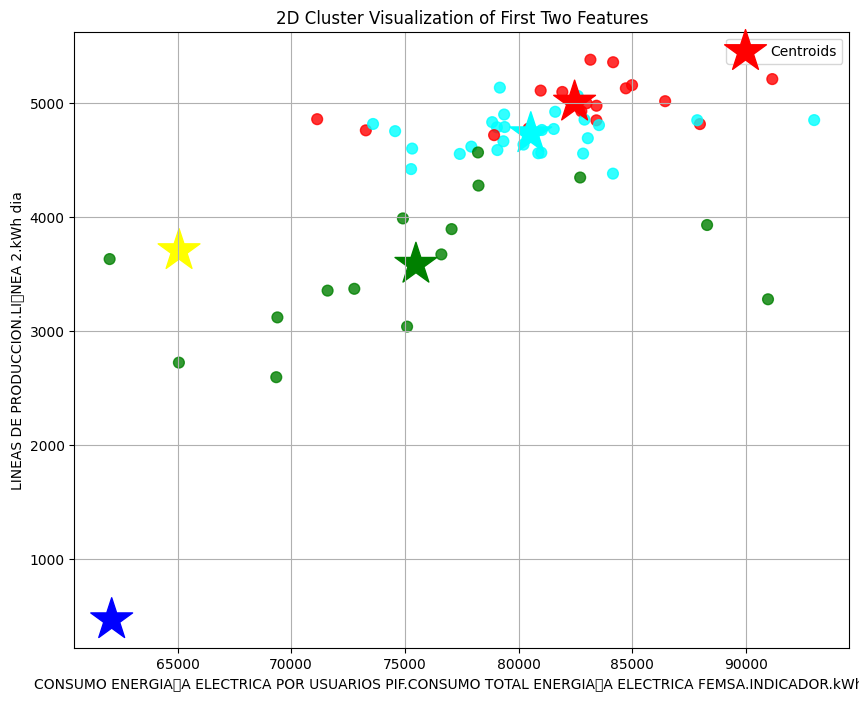

In [256]:
plt.figure(figsize=(10, 8))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=asignar, s=60, alpha=0.8)
plt.scatter(C[:, 0], C[:, 1], marker='*', s=1000, c=colores, label='Centroids')
plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title('2D Cluster Visualization of First Two Features')
plt.legend()
plt.grid(True)
plt.show()

In [270]:
# Calculate and display the mean of indicators for each cluster
cluster_means = indicadores.groupby(labels).mean()
display(cluster_means)

,indicador_energia_planta.lb/kw,indicador_energia_L2.lb/kw,indicador_energia_L3.lb/kw,indicador_energia_L4.lb/kw,indicador_energia_L5.lb/kw,indicador_energia_L6.lb/kw,indicador_energia_L7.lb/kw,indicador_refrigeracion.lb/kw,indicador_aire_comprimido.lb/kw
0,29.735163,227.103418,72.029857,70.565533,188.397662,140.532427,46.600848,73.481719,662.739541
1,22.105232,175.611261,74.286099,67.949885,180.771968,34.237374,7.207806,66.717979,501.630079
2,14.474631,0.000000,0.000000,28.771730,102.102356,0.000000,0.000000,63.550046,416.605169
3,26.661892,199.335700,80.668208,68.171138,177.065500,44.309558,15.368896,70.636869,576.018022
4,15.744846,212.011869,31.065421,0.000000,0.000000,20.780914,16.306436,78.091882,389.946971


In [271]:
# Calculate and display the count of days assigned to each cluster
cluster_counts = pd.Series(labels).value_counts().sort_index()
display(cluster_counts)

,count
0,17
1,15
2,1
3,27
4,1


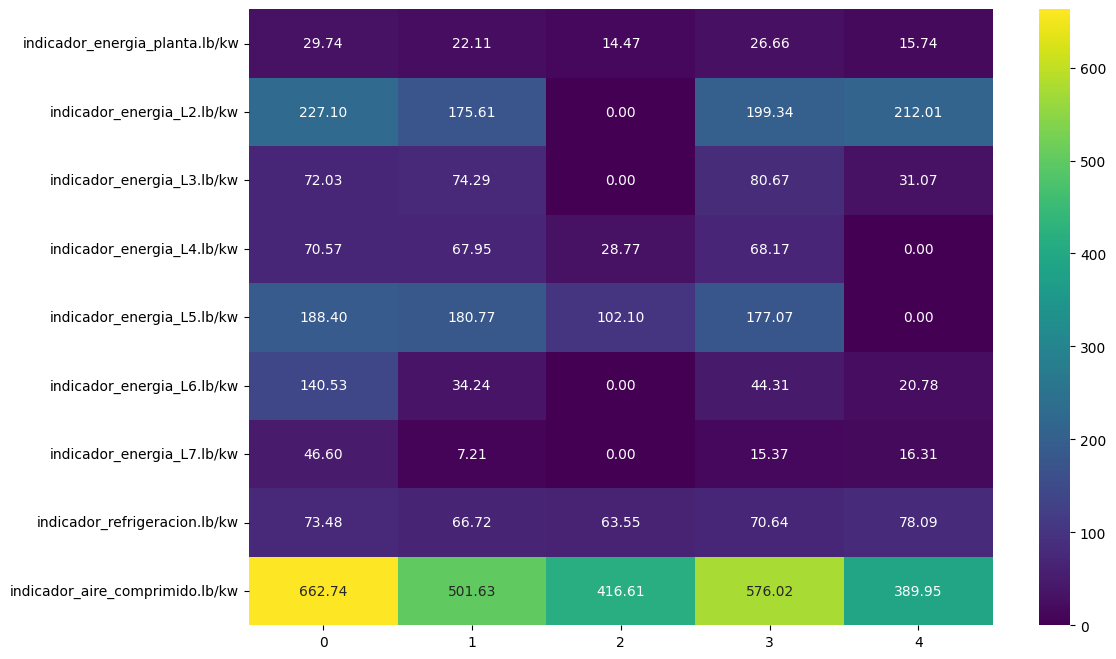

In [272]:
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_means.transpose(), annot=True, cmap='viridis', fmt='.2f')
#plt.title('Heatmap of Cluster Means for Indicators')
#plt.xlabel('Cluster')
#plt.ylabel('Indicador')
plt.show()

In [273]:
# Calculate the variance of indicators for each cluster
cluster_variances = indicadores.groupby(labels).var()
display(cluster_variances)

,indicador_energia_planta.lb/kw,indicador_energia_L2.lb/kw,indicador_energia_L3.lb/kw,indicador_energia_L4.lb/kw,indicador_energia_L5.lb/kw,indicador_energia_L6.lb/kw,indicador_energia_L7.lb/kw,indicador_refrigeracion.lb/kw,indicador_aire_comprimido.lb/kw
0,2.352699,125.273003,214.420320,108.682178,281.118109,52273.935087,7305.814156,76.804399,6136.226781
1,13.279053,895.976153,320.130893,136.311505,632.393680,2583.853689,65.732490,219.774348,5886.629909
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6.831136,270.588011,109.705470,115.307260,537.502352,2629.139165,770.505134,130.934807,4227.897047
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


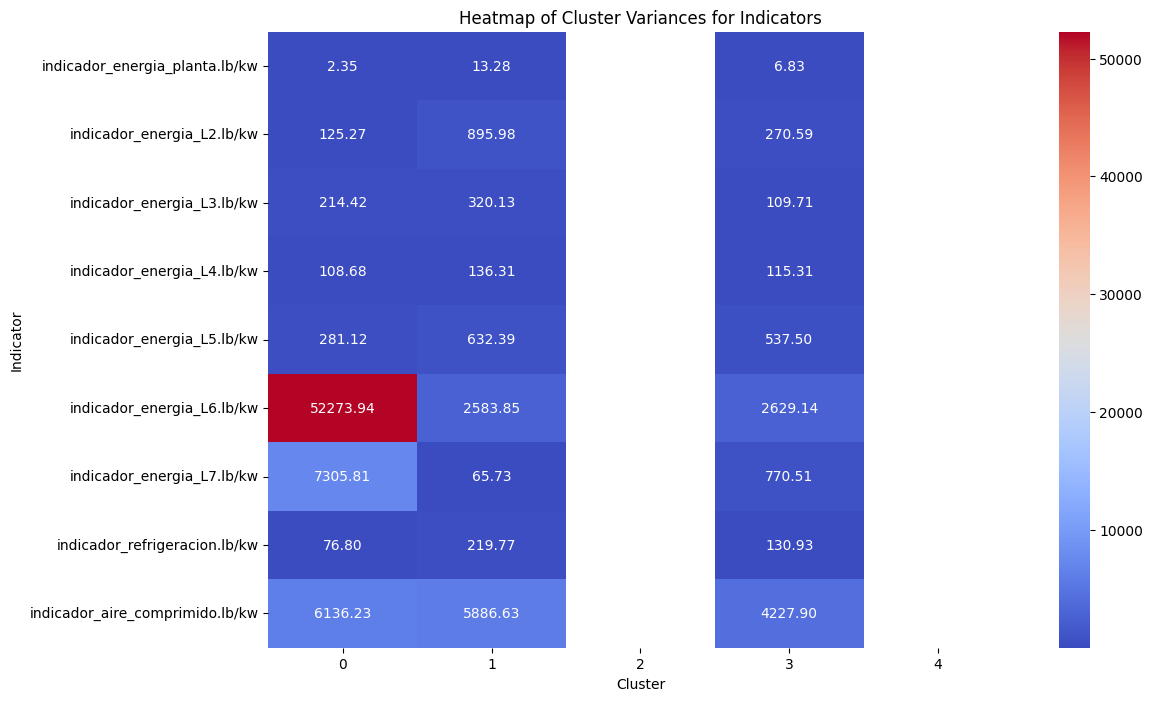

In [274]:
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_variances.transpose(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap of Cluster Variances for Indicators')
plt.xlabel('Cluster')
plt.ylabel('Indicator')
plt.show()

In [275]:
max_variance_per_indicator = cluster_variances.max()
highest_variance_indicator = max_variance_per_indicator.idxmax()
max_variance_value = max_variance_per_indicator.max()

print(f"El indicador con la mayor varianza en todos los clústeres es '{highest_variance_indicator}' con una varianza de {max_variance_value:.2f}.")

El indicador con la mayor varianza en todos los clústeres es 'indicador_energia_L6.lb/kw' con una varianza de 52273.94.
